# Qwen3VL-4B LoRA Fine-tuning on BDD100K

This notebook provides an optimized workflow for:
- Setting up Qwen3VL-4B with LoRA fine-tuning
- Training on BDD100K dataset (JSONL format)
- Real-time monitoring and visualization


### System Requirements:
- VRAM: 24GB+ NVIDIA GeForce RTX 5090
- Python version 3.11.9
- Framework: HuggingFace Transformers + PEFT
- Optimization: LoRA with gradient checkpointing and vision token capping 


## 1. Environment Setup and Dependencies

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [ ]:
# Install required packages for Qwen3VL training
%pip install -q peft==0.11.0
%pip install -q datasets==2.19.0
%pip install -q torch torchvision
%pip install -q wandb
%pip install -q matplotlib seaborn scikit-learn
%pip install -q tqdm
%pip install -q numpy pandas pillow flash-attn --no-build-isolation
%pip install hf_xet #important for faster hf downloads

In [3]:
import accelerate
import peft
import transformers

print(accelerate.__version__)
print(peft.__version__)
print(transformers.__version__)

1.13.0
0.11.0
4.57.0


In [4]:
# Import all required libraries
import os
import sys
import json
import warnings
from pathlib import Path
from datetime import datetime

# Data handling
import numpy as np
import pandas as pd
from PIL import Image

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader

# Progress bars
from tqdm.auto import tqdm

# HuggingFace - Model loading and training
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    TrainingArguments,
    Trainer,
)

# PEFT - Parameter Efficient Fine-Tuning (LoRA)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

# HuggingFace Datasets
from datasets import load_dataset, DatasetDict

# Supporting libraries
import accelerate
import bitsandbytes as bnb
import wandb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

warnings.filterwarnings("ignore")
print("All imports successful")

W0706 09:45:35.648000 6700 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


All imports successful


In [5]:
# Check GPU availability and setup device
# This determines where tensors will be computed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        memory_gb = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  Total Memory: {memory_gb:.2f} GB")

Device: cuda
CUDA Available: True
GPU Count: 1
GPU 0: NVIDIA GeForce RTX 5090
  Total Memory: 34.19 GB


## 2. Configuration and Hyperparameters

In [8]:
# Global configuration - Optimized for Speed and Throughput
# Modify these values to adapt the training to your setup
CONFIG = {
    "model_name": "Qwen/Qwen3-VL-4B-Instruct",
    "model_type": "qwen3_vl",

    # Dataset paths
    "dataset_format": "jsonl",
    "train_jsonl": r"C:/Users/becker/Documents/Thesis/dataset/train.jsonl",
    "val_jsonl": r"C:/Users/becker/Documents/Thesis/dataset/val.jsonl",
    "image_base_path": r"C:/Users/becker/Documents/Thesis/dataset/images",

    # LoRA configuration
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "target_modules": [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    "bias": "none",

    # OPTIMIZED TRAINING HYPERPARAMETERS
    "batch_size": 4,                     
    "gradient_accumulation_steps": 2,    
    "learning_rate": 2e-4,                
    "warmup_steps": 200,
    "num_train_epochs": 1,
    "max_steps": -1,
    "weight_decay": 0.01,

    # Memory and precision optimizations
    "gradient_checkpointing": True,       
    "bf16": True,
    "tf32": True,
    "max_grad_norm": 1.0,

    # Image resolution token limits (Exponential speedup for VLMs)
    "min_pixels": 256 * 256,
    "max_pixels": 384 * 384,              # Caps sequence lengths to prevent token explosion

    # Saving and evaluation strategies (Reduced frequency to save overhead)
    "output_dir": r"./qwen3vl_bdd100k_lora",
    "save_strategy": "steps",
    "eval_strategy": "steps",
    "save_steps": 1000,
    "eval_steps": 1000,
    "logging_steps": 20,
    "save_total_limit": 2,
    "load_best_model_at_end": True,
    "metric_for_best_model": "loss",

    "use_wandb": False,
    "project_name": "qwen3vl-bdd100k",
    "run_name": f"qwen3vl-lora-{datetime.now().strftime('%Y%m%d_%H%M%S')}",

    "seed": 42,
    "dataloader_num_workers": 0,          # Enabled workers to handle high-speed image preprocessing, change to 2 on another train try
    "dataloader_pin_memory": True,
    "remove_unused_columns": False,
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
with open(os.path.join(CONFIG["output_dir"], "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Configuration optimized and loaded.")
print(f"Effective Batch Size: {CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps'] * 2} ")

Configuration optimized and loaded.
Effective Batch Size: 16 


In [9]:
#Make sure all paths and files exist before proceeding with training
print("Validating paths and files...")
print("-" * 80)

jsonl_files = [
    ("Train JSONL", CONFIG["train_jsonl"]),
    ("Val JSONL", CONFIG["val_jsonl"]),
]

all_exist = True
for name, path in jsonl_files:
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    print(f"[{status}] {name}: {path}")
    if not exists:
        all_exist = False

image_path_exists = os.path.exists(CONFIG["image_base_path"])
status = "OK" if image_path_exists else "MISSING"
print(f"[{status}] Image Base Path: {CONFIG['image_base_path']}")
if not image_path_exists:
    all_exist = False

print("-" * 80)
if all_exist:
    print("Validation complete. All files ready.")

Validating paths and files...
--------------------------------------------------------------------------------
[OK] Train JSONL: C:/Users/becker/Documents/Thesis/dataset/train.jsonl
[OK] Val JSONL: C:/Users/becker/Documents/Thesis/dataset/val.jsonl
[OK] Image Base Path: C:/Users/becker/Documents/Thesis/dataset/images
--------------------------------------------------------------------------------
Validation complete. All files ready.


## 3. Load Model and Processor

In [10]:
print("Loading optimized model and processor...")
processor = AutoProcessor.from_pretrained(CONFIG["model_name"])

model = AutoModelForImageTextToText.from_pretrained(
    CONFIG["model_name"],
    # device_map="auto",
    dtype=torch.bfloat16,
    attn_implementation="sdpa", 
    trust_remote_code=True,
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded. Total parameters: {total_params / 1e9:.2f}B")

Loading optimized model and processor...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded. Total parameters: 4.44B


## 4. BDD100K Dataset Class Definition

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

# Inject yor resolution limits directly into the processor global settings
# This ensures SFTTrainer respects speed targets automatically during collation
processor.image_processor.min_pixels = CONFIG["min_pixels"]
processor.image_processor.max_pixels = CONFIG["max_pixels"]


class BDD100KDataset(Dataset):
    def __init__(self, jsonl_path, image_base_path="", max_samples=None):
        self.jsonl_path = jsonl_path
        self.image_base_path = image_base_path
        self.samples = []

        print(f"Loading data from {os.path.basename(jsonl_path)}...")
        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    sample = json.loads(line.strip())
                    self.samples.append(sample)
                    if max_samples and len(self.samples) >= max_samples:
                        break
                except json.JSONDecodeError:
                    continue

        print(f"Loaded {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Pull the image path directly from the root key
        image_path = sample.get("image", "")
        
        if self.image_base_path and not os.path.isabs(image_path):
            full_image_path = os.path.join(self.image_base_path, image_path)
        else:
            full_image_path = image_path

        # Safely resolve and open the image
        try:
            image = Image.open(full_image_path).convert("RGB")
        except Exception as e:
            print(f"Warning: Could not load {full_image_path}. Using fallback canvas. Error: {e}")
            # Use your optimized fast resolution size as a fallback canvas
            image = Image.new("RGB", (384, 384), color="black")

        # Pass the raw elements to the trainer.
        # SFTTrainer will automatically handle tokenization and create the perfect loss masks.
        return {
            "messages": sample["messages"],
            "images": [image]  # Qwen processor expects images inside a list wrapper
        }

## 5. Load Training, Validation

In [ ]:
print("Loading datasets...")
try:
    train_dataset = BDD100KDataset(CONFIG["train_jsonl"], image_base_path=CONFIG["image_base_path"])
    val_dataset = BDD100KDataset(CONFIG["val_jsonl"], image_base_path=CONFIG["image_base_path"])
except Exception as e:
    print(f"Error loading datasets: {e}")
    raise

# Calculate accurate step metrics based on your actual gradient accumulation choices
total_samples = len(train_dataset)
steps_per_epoch = total_samples // (CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps'])

print("\n--- Dataset Profile ---")
print(f"Train samples loaded: {total_samples}")
print(f"Validation samples loaded: {len(val_dataset)}")
print(f"Optimization Steps per Epoch: {steps_per_epoch}")
print(f"Total Projected Training Steps (across {CONFIG['num_train_epochs']} epochs): {steps_per_epoch * CONFIG['num_train_epochs']}")

Loading datasets...
Loading data from train.jsonl...
Loaded 393277 samples
Loading data from val.jsonl...
Loaded 56199 samples

--- Dataset Profile ---
Train samples loaded: 393277
Validation samples loaded: 56199
Optimization Steps per Epoch: 49159
Total Projected Training Steps (across 1 epochs): 49159


In [ ]:
print("Verifying layout token size drops...")

# Grab the raw sample from our updated dataset
sample = train_dataset[0]
print(f"Raw image format: {type(sample['images'][0])}")
print(f"Original image resolution (Width, Height): {sample['images'][0].size}")

# Simulate what the data collator does using your CONFIG limits
mock_processed = processor(
    text=["<|im_start|>user\n<|image_pad|><|im_end|>"], 
    images=sample['images'],
    return_tensors="pt",
    min_pixels=CONFIG["min_pixels"],
    max_pixels=CONFIG["max_pixels"]
)

print(f"Capped Vision Pixel Tensor Shape: {mock_processed['pixel_values'].shape}")

# For Qwen3-VL, image_grid_thw tells you exactly how many patches are generated
if "image_grid_thw" in mock_processed:
    grid = mock_processed["image_grid_thw"]
    print(f"Image Grid patches [Temporal, Height, Width]: {grid.tolist()[0]}")
    print(f"Total Visual Tokens generated for this image: {grid[0][1] * grid[0][2]}")

Verifying layout token size drops...
Raw image format: <class 'PIL.Image.Image'>
Original image resolution (Width, Height): (1280, 720)
Capped Vision Pixel Tensor Shape: torch.Size([576, 1536])
Image Grid patches [Temporal, Height, Width]: [1, 18, 32]
Total Visual Tokens generated for this image: 576


## 6. LoRA Configuration and Model Preparation

In [38]:
print("Preparing model with LoRA adaptations...")

if CONFIG["gradient_checkpointing"]:
    model.gradient_checkpointing_enable()
    print("Gradient checkpointing verified active.")

if hasattr(model, 'enable_input_require_grads'):
    model.enable_input_require_grads()

lora_config = LoraConfig(
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    target_modules=CONFIG["target_modules"],
    lora_dropout=CONFIG["lora_dropout"],
    bias=CONFIG["bias"],
    task_type="CAUSAL_LM",
)
# Apply LoRA to model
model = get_peft_model(model, lora_config)
# Print trainable parameter statistics
model.print_trainable_parameters()
print()
print("LoRA configuration applied to model")
print(f"  Rank (r): {CONFIG['lora_r']}")
print(f"  Alpha: {CONFIG['lora_alpha']}")
print(f"  Dropout: {CONFIG['lora_dropout']}")
print(f"  Target modules: {len(CONFIG['target_modules'])} layers")
print()
print("Model is now ready for training")

Preparing model with LoRA adaptations...
Gradient checkpointing verified active.
trainable params: 33,030,144 || all params: 4,470,845,952 || trainable%: 0.7388

LoRA configuration applied to model
  Rank (r): 16
  Alpha: 32
  Dropout: 0.05
  Target modules: 7 layers

Model is now ready for training


## 7. Training Setup and Execution

In [14]:
# Configure training arguments for HuggingFace Trainer
training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_train_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    learning_rate=CONFIG["learning_rate"],
    warmup_steps=CONFIG["warmup_steps"],
    weight_decay=CONFIG["weight_decay"],
    
    bf16=CONFIG["bf16"],
    tf32=CONFIG["tf32"],
    max_grad_norm=CONFIG["max_grad_norm"],
    gradient_checkpointing=CONFIG["gradient_checkpointing"],
    
    eval_strategy=CONFIG["eval_strategy"],
    eval_steps=CONFIG["eval_steps"],
    save_strategy=CONFIG["save_strategy"],
    save_steps=CONFIG["save_steps"],
    logging_steps=CONFIG["logging_steps"],
    save_total_limit=CONFIG["save_total_limit"],
    load_best_model_at_end=CONFIG["load_best_model_at_end"],
    metric_for_best_model=CONFIG["metric_for_best_model"],
    
    seed=CONFIG["seed"],
    dataloader_num_workers=CONFIG["dataloader_num_workers"],
    dataloader_pin_memory=CONFIG["dataloader_pin_memory"],
    remove_unused_columns=CONFIG["remove_unused_columns"],
    report_to="none",
)
print(" Training arguments configured")
print(f"  Epochs: {CONFIG['num_train_epochs']}")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Eval steps:  {CONFIG['eval_steps']}")


 Training arguments configured
  Epochs: 1
  Batch size: 4
  Eval steps:  1000


In [ ]:
#VisionCollator

from typing import Dict, List, Any
import torch

class VisionLanguageCollator:
    def __init__(self, processor, min_pixels, max_pixels):
        self.processor = processor
        self.min_pixels = min_pixels
        self.max_pixels = max_pixels
        
        # DYNAMICALLY detect the exact token sequence for '<|im_start|>assistant\n'
        self.assistant_prefix = self.processor.tokenizer.encode(
            "<|im_start|>assistant\n", 
            add_special_tokens=False
        )

    def __call__(self, batch: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        # Reconstruct texts and collect raw images from our clean dataset elements
        texts = []
        images = []
        
        for sample in batch:
            # Render the correct structural text tokens using the official chat layout
            prompt = self.processor.apply_chat_template(
                sample["messages"], 
                tokenize=False, 
                add_generation_prompt=False
            )
            texts.append(prompt)
            # Extends the list with the raw PIL image object
            images.extend(sample["images"])

        # Let the processor safely batch tokenise and adjust aspect ratios
        processed = self.processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
            truncation=False,
            min_pixels=self.min_pixels,
            max_pixels=self.max_pixels
        )

        input_ids = processed["input_ids"]
        attention_mask = processed["attention_mask"]
        
        # Build target labels matching input_ids
        labels = input_ids.clone()
        pad_token_id = self.processor.tokenizer.pad_token_id or 0

        # Target-Only Loss Masking per row
        for i in range(labels.shape[0]):
            seq_list = input_ids[i].tolist()
            assistant_idx = self._find_sublist(seq_list, self.assistant_prefix)
            
            if assistant_idx != -1:
                # Mask out all system prompts, user questions, and vision tokens with -100
                cutoff = assistant_idx + len(self.assistant_prefix)
                labels[i, :cutoff] = -100
            else:
                # Fallback safeguard if the assistant token sequence isn't found
                labels[i, :] = -100
                
        # Mask out any trailing padding tokens
        labels[labels == pad_token_id] = -100

        # Pack everything safely for the model
        output = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "pixel_values": processed["pixel_values"],
            "labels": labels,
        }
        
        # Preserve specialized positional metadata if generated by the processor
        if "image_grid_thw" in processed:
            output["image_grid_thw"] = processed["image_grid_thw"]
            
        return output

    def _find_sublist(self, main_list, sub_list):
        for idx in range(len(main_list) - len(sub_list) + 1):
            if main_list[idx : idx + len(sub_list)] == sub_list:
                return idx
        return -1

# Instantiate dynamic collator safely
data_collator = VisionLanguageCollator(
    processor=processor,
    min_pixels=CONFIG["min_pixels"],
    max_pixels=CONFIG["max_pixels"]
)
print("VisionLanguageCollator successfully initialized!")

VisionLanguageCollator successfully initialized!


In [ ]:
import traceback
import torch

print("Verifying gradient pathways via an isolated single-threaded batch...")

# Force the target to your RTX 5090
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Moving model weights explicitly to: {device}")

try:
    # Safely push the model to the GPU since it was loaded on the CPU
    model.to(device)
    model.train()

    # Grab raw samples and collate them manually
    raw_samples = [train_dataset[i] for i in range(2)]  
    sample_batch = data_collator(raw_samples)          

    # Cast batch tensors to match the GPU device
    inputs = {
        k: v.to(device) if isinstance(v, torch.Tensor) else v
        for k, v in sample_batch.items()
    }

    # Compute loss forward pass
    outputs = model(**inputs)
    loss = outputs.loss if hasattr(outputs, "loss") else outputs[0]
    print(f"Isolated Batch Loss computed successfully: {loss.item():.6f}")

    # Trigger backward pass calculation
    loss.backward()

    # Check if weights across LoRA targets received active gradients
    gradient_flow_ok = False
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            grad_norm = param.grad.norm().item()
            if grad_norm > 0:
                gradient_flow_ok = True
                print(f"  [Success] Active gradient found on target: {name} (Norm: {grad_norm:.6f})")
                break  

    if gradient_flow_ok:
        print("\nVerification PASSED: Gradient flow pathways successfully initialized.")
    else:
        print("\nVerification FAILED: Parameters are locked or gradients are zero.")

except Exception as e:
    gradient_flow_ok = False
    print(f"\nVerification blocked by runtime error: {e}")
    traceback.print_exc()

finally:
    # Flush the test gradients, but LEAVE the model on the GPU
    if "model" in locals():
        model.zero_grad()
        print("Gradients flushed clean. Model remains securely on the GPU for training.")

Verifying gradient pathways via an isolated single-threaded batch...
Moving model weights explicitly to: cuda:0


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Isolated Batch Loss computed successfully: 1.397900
  [Success] Active gradient found on target: base_model.model.base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_B.default.weight (Norm: 0.052490)

Verification PASSED: Gradient flow pathways successfully initialized.
Gradients flushed clean. Model remains securely on the GPU for training.


In [ ]:
# Main training cell
# Start training ONLY if verification passed

from transformers import TrainingArguments, Trainer

# Start training ONLY if verification passed
if not gradient_flow_ok:
    print("Halted due to verification failure.")
else:
    print("Initializing Training Configuration...")
    training_args = TrainingArguments(
        output_dir=CONFIG["output_dir"],
        save_strategy=CONFIG["save_strategy"],
        eval_strategy=CONFIG["eval_strategy"],
        save_steps=CONFIG["save_steps"],
        eval_steps=CONFIG["eval_steps"],
        logging_steps=CONFIG["logging_steps"],
        save_total_limit=CONFIG["save_total_limit"],
        load_best_model_at_end=CONFIG["load_best_model_at_end"],
        metric_for_best_model=CONFIG["metric_for_best_model"],
        
        # Sizing optimized for RTX 5090 speed targets
        per_device_train_batch_size=CONFIG["batch_size"],
        per_device_eval_batch_size=CONFIG["batch_size"],
        gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
        
        learning_rate=CONFIG["learning_rate"],
        warmup_steps=CONFIG["warmup_steps"],
        num_train_epochs=CONFIG["num_train_epochs"],
        weight_decay=CONFIG["weight_decay"],
        max_grad_norm=CONFIG["max_grad_norm"],
        
        # Speed & Precision options
        bf16=CONFIG["bf16"],
        tf32=CONFIG["tf32"],
        gradient_checkpointing=CONFIG["gradient_checkpointing"],
        
        dataloader_num_workers=CONFIG["dataloader_num_workers"],
        dataloader_pin_memory=CONFIG["dataloader_pin_memory"],
        remove_unused_columns=CONFIG["remove_unused_columns"],
        report_to="none",
        seed=CONFIG["seed"]
    )

    print("Assembling Trainer pipeline...")
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator  
    )
    print("Trainer successfully initialized.")
    
    print("Starting optimized training loop...")
    try:
        trainer.train() #comment to run more analysis on the training without trigerring another train run
        print("Training complete.")
    except KeyboardInterrupt:
        print("Training paused by user.")

Initializing Training Configuration...
Assembling Trainer pipeline...
Trainer successfully initialized.
Starting optimized training loop...


Step,Training Loss,Validation Loss
1000,0.387400,0.396490
2000,0.380800,0.389348
3000,0.390800,0.388845
4000,0.353700,0.383604
5000,0.370900,0.381374
6000,0.364200,0.381872
7000,0.363200,0.381261
8000,0.363400,0.376550
9000,0.373600,0.374413
10000,0.376600,0.374850


Training complete.


## 8. Save Trained Model
 The model directory contains LoRA weights, config, and processor files necessary for loading and inference

In [18]:
# Save the trained LoRA model for later inference
lora_save_path = os.path.join(CONFIG["output_dir"], "final_model")
os.makedirs(lora_save_path, exist_ok=True)
model.save_pretrained(lora_save_path)
processor.save_pretrained(lora_save_path)
print(f"Optimized Model weights preserved at {lora_save_path}")

Optimized Model weights preserved at ./qwen3vl_bdd100k_lora\final_model


**Visualize training results**

Upgraded chart exported to: C:\Users\becker\Documents\Thesis\qwen3vl_bdd100k_lora\train_val_loss.png


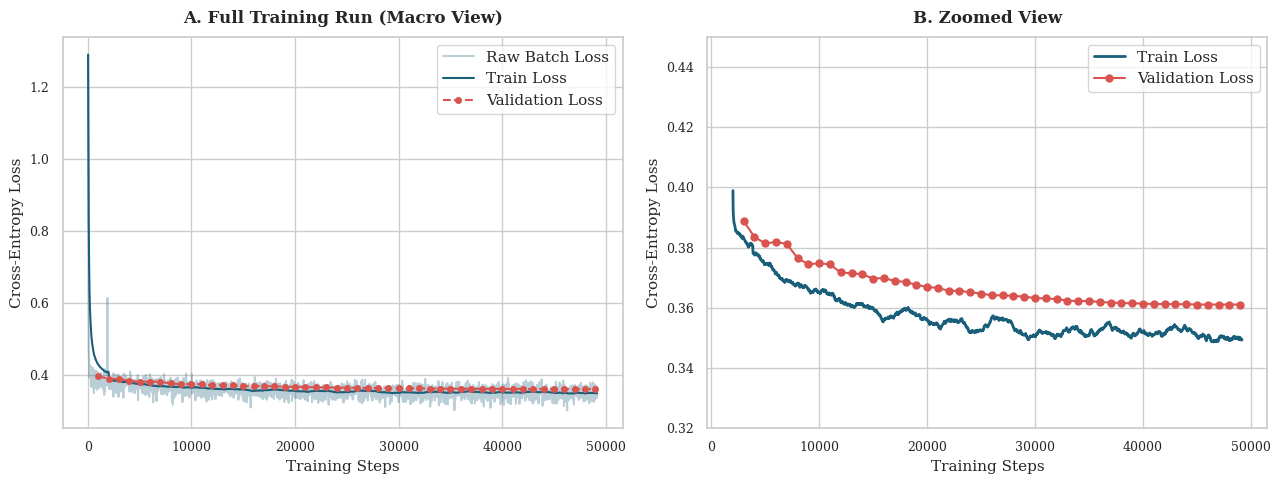

In [61]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean, publication-ready thesis styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif", 
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})

# Read history from your checkpoint folder
state_path = r"C:\Users\becker\Documents\Thesis\qwen3vl_bdd100k_lora\checkpoint-49160\trainer_state.json"
with open(state_path, "r") as f:
    state_data = json.load(f)
    history = state_data.get("log_history", [])

# Separate metrics
train_steps, train_losses = [], []
eval_steps, eval_losses = [], []

for log in history:
    if "loss" in log:
        train_steps.append(log["step"])
        train_losses.append(log["loss"])
    if "eval_loss" in log and "step" in log:
        eval_steps.append(log["step"])
        eval_losses.append(log["eval_loss"])

# Convert to Pandas for smoothing operations
df_train = pd.DataFrame({"step": train_steps, "loss": train_losses})
# Apply a rolling average window to smooth out high-frequency batch noise
df_train["smoothed_loss"] = df_train["loss"].rolling(window=100, min_periods=1).mean()

# Create a Side-by-Side Double Subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df_train["step"], df_train["loss"], color="#1a5f7a", alpha=0.3, label="Raw Batch Loss")
ax1.plot(df_train["step"], df_train["smoothed_loss"], color="#1a5f7a", linewidth=1.5, label="Train Loss")
ax1.plot(eval_steps, eval_losses, color="#d9534f", linestyle="--", marker="o", markersize=4, label="Validation Loss")

ax1.set_title("A. Full Training Run (Macro View)", weight="bold", pad=10)
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend(loc="upper right", frameon=True, facecolor="white")

# Filter out the initial burn-in phase 
df_zoomed = df_train[df_train["step"] > 2000]
eval_zoomed_steps = [s for s in eval_steps if s > 2000]
eval_zoomed_losses = [l for s, l in zip(eval_steps, eval_losses) if s > 2000]

ax2.plot(df_zoomed["step"], df_zoomed["smoothed_loss"], color="#1a5f7a", linewidth=2, label="Train Loss")
ax2.plot(eval_zoomed_steps, eval_zoomed_losses, color="#d9534f", linestyle="-", marker="o", markersize=5, label="Validation Loss")

# Set strict Y-limits to intentionally blow up the micro-trends
ax2.set_ylim(0.32, 0.45) 
ax2.set_title("B. Zoomed View", weight="bold", pad=10)
ax2.set_xlabel("Training Steps")
ax2.set_ylabel("Cross-Entropy Loss")
ax2.legend(loc="upper right", frameon=True, facecolor="white")

plt.tight_layout()

# Save the upgraded figure
save_dir = r"C:\Users\becker\Documents\Thesis\qwen3vl_bdd100k_lora"
save_path = os.path.join(save_dir, "train_val_loss.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Upgraded chart exported to: {save_path}")
plt.show()

## 9. Evaluate on Test Dataset
- Catches Overfitting (The Loss Check)
- Benchmarks Speed and Efficiency
- Acts as a Safety Net

In [19]:
print("Running final check over validation split...")
# Leaving this empty automatically evaluates the model on your validation dataset
eval_results = trainer.evaluate() 

print("Final Evaluation Results:")
print("-" * 80)
for key, value in eval_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Save results
results_path = os.path.join(CONFIG["output_dir"], "final_evaluation_results.json")
with open(results_path, "w") as f:
    json.dump(eval_results, f, indent=2)

print()
print(f"Results saved to {results_path}")

Running final check over validation split...


Final Evaluation Results:
--------------------------------------------------------------------------------
eval_loss: 0.3611
eval_runtime: 3794.5315
eval_samples_per_second: 14.8110
eval_steps_per_second: 3.7030
epoch: 1.0000

Results saved to ./qwen3vl_bdd100k_lora\final_evaluation_results.json
